# UruTracker - Radar de Emenda Pix Parada

Identifica municipios com emenda Pix aprovada e obra parada, ranqueados por urgencia.
Dados: API Transferegov | Periodo: 2024+

## Parte 1 - Carga e Integracao dos Dados

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date

DADOS = Path("../data_extraction")
HOJE = pd.Timestamp(date.today())

In [9]:
plano_acao     = pd.read_csv(DADOS / "plano_acao_especial.csv", encoding="utf-8-sig")
plano_trabalho = pd.read_csv(DADOS / "plano_trabalho_especial.csv", encoding="utf-8-sig")
executor       = pd.read_csv(DADOS / "executor_especial.csv", encoding="utf-8-sig")
finalidade     = pd.read_csv(DADOS / "finalidade_especial.csv", encoding="utf-8-sig")

print(plano_acao.shape, plano_trabalho.shape, executor.shape, finalidade.shape)

(33709, 9) (56405, 6) (57355, 3) (94462, 2)


In [10]:
plano_trabalho["data_fim_execucao_plano_trabalho"] = pd.to_datetime(
    plano_trabalho["data_fim_execucao_plano_trabalho"], errors="coerce"
)

plano_acao["valor_total"] = (
    plano_acao["valor_custeio_plano_acao"].fillna(0)
    + plano_acao["valor_investimento_plano_acao"].fillna(0)
)

finalidade_agg = (
    finalidade.groupby("id_executor")["area_politica_publica_pt"]
    .apply(lambda x: " | ".join(sorted(x.dropna().unique())))
    .reset_index()
    .rename(columns={"area_politica_publica_pt": "setor"})
)

executor_primeiro = executor.drop_duplicates("id_plano_acao", keep="first")

In [11]:
df = plano_acao.merge(plano_trabalho, on="id_plano_acao", how="left")
df = df.merge(executor_primeiro[["id_plano_acao", "id_executor", "objeto_executor"]], on="id_plano_acao", how="left")
df = df.merge(finalidade_agg, on="id_executor", how="left")

print(f"Total: {len(df)} emendas")
df.head(3)

Total: 33709 emendas


,id_plano_acao,ano_plano_acao,nome_beneficiario_plano_acao,cnpj_beneficiario_plano_acao,uf_beneficiario_plano_acao,nome_parlamentar_emenda_plano_acao,valor_custeio_plano_acao,valor_investimento_plano_acao,situacao_plano_acao,valor_total,situacao_plano_trabalho,ind_justificativa_prorrogacao_paralizacao_pt,ind_justificativa_prorrogacao_atraso_pt,data_inicio_execucao_plano_trabalho,data_fim_execucao_plano_trabalho,id_executor,objeto_executor,setor
0,83398,2025,MUNICIPIO DE QUILOMBO,83021865000161,SC,Fabio Schiochet,0.0,990000.0,CIENTE,990000.0,APROVADO,False,False,2025-09-09T00:00:00,2028-09-09,38161.0,PAVIMENTAÇÃO EM TRECHOS DE ESTRADAS VICINAIS D...,Infraestrutura Urbana | Promoção da Produção ...
1,71010,2024,MUNICIPIO DE OSASCO,46523171000104,SP,Jefferson Campos,0.0,2000000.0,CIENTE,2000000.0,CONCLUIDO_NT_TCU,False,False,2024-12-12T00:00:00,2025-12-12,19901.0,Construção de 1 Ecoponto e 1 Quadra Poliespor...,Desporto Comunitário | Preservação e Conservaç...
2,74531,2024,MUNICIPIO DE MIRADOURO,17947623000179,MG,Delegada Ione,0.0,800000.0,CIENTE,800000.0,CONCLUIDO_NT_TCU,False,False,2024-07-03T00:00:00,2025-01-03,1476.0,META 1 EXECUÇÃO DE OBRAS DO ´PRONTO ATENDIM...,Atenção Básica


## Parte 2 - Classificacao e KPIs

### Classificacao de emendas paradas

Uma emenda e considerada **parada** se atende ao menos uma das condicoes:
- **A:** situacao_plano_trabalho == APROVADO
- **C:** prazo de execucao vencendo em menos de 90 dias

Urgencia: PRAZO_CRITICO > APROVADO_PENDENTE

In [12]:
CONCLUIDOS = {"CONCLUIDO", "CONCLUIDO_NT_TCU", "CONCLUIDO_PRESTACAO_CONTAS"}

cond_A = df["situacao_plano_trabalho"] == "APROVADO"
cond_C = (
    (df["data_fim_execucao_plano_trabalho"] < (HOJE + pd.Timedelta(days=90)))
    & (~df["situacao_plano_trabalho"].isin(CONCLUIDOS))
)

df["parado"] = cond_A | cond_C
df_parado = df[df["parado"]].copy()

def urgencia(row):
    if pd.notna(row["data_fim_execucao_plano_trabalho"]) and \
       row["data_fim_execucao_plano_trabalho"] < (HOJE + pd.Timedelta(days=90)):
        return "PRAZO_CRITICO"
    return "APROVADO_PENDENTE"

df_parado["urgencia"] = df_parado.apply(urgencia, axis=1)
df_parado["dias_para_prazo"] = (df_parado["data_fim_execucao_plano_trabalho"] - HOJE).dt.days
df_parado["rank"] = df_parado["urgencia"].map({"PRAZO_CRITICO": 1, "APROVADO_PENDENTE": 2})
df_parado = df_parado.sort_values(["rank", "dias_para_prazo"])

print(f"Emendas paradas: {len(df_parado)} ({len(df_parado)/len(df)*100:.1f}%)")
df_parado["urgencia"].value_counts()

Emendas paradas: 18872 (56.0%)


urgencia
APROVADO_PENDENTE    17974
PRAZO_CRITICO          898
Name: count, dtype: int64

In [13]:
print(f"Total emendas paradas : {len(df_parado)}")
print(f"Valor total           : R$ {df_parado['valor_total'].sum()/1e6:.1f}M")
print(f"Municipios            : {df_parado['nome_beneficiario_plano_acao'].nunique()}")
print(f"Prazo critico (<90d)  : {(df_parado['urgencia']=='PRAZO_CRITICO').sum()}")

Total emendas paradas : 18872
Valor total           : R$ 13267.7M
Municipios            : 4642
Prazo critico (<90d)  : 898


## Parte 3 - Analises e Visualizacoes

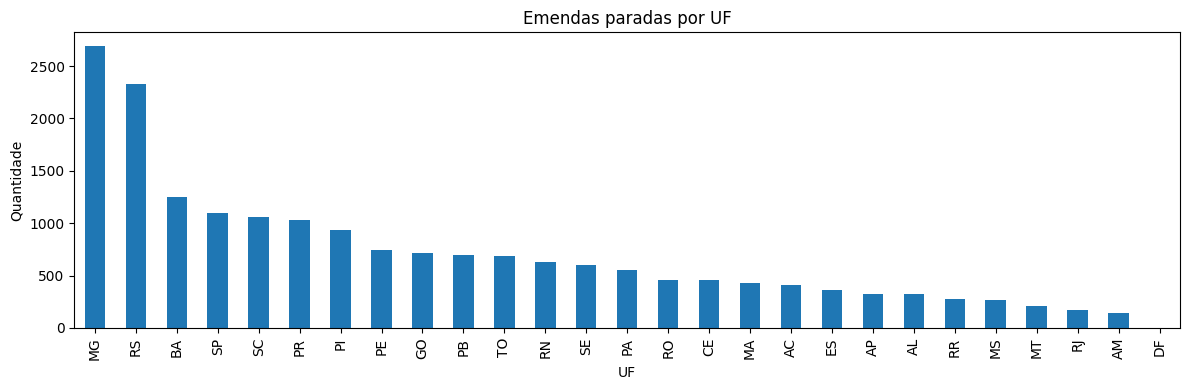

In [14]:
por_uf = df_parado.groupby("uf_beneficiario_plano_acao")["id_plano_acao"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
por_uf.plot(kind="bar", ax=ax)
ax.set_title("Emendas paradas por UF")
ax.set_xlabel("UF")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

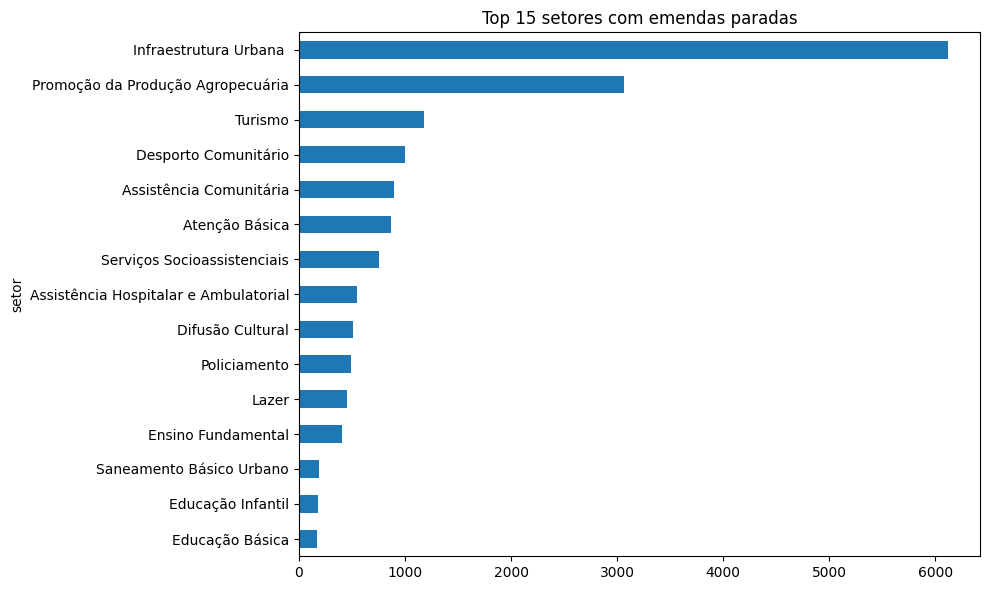

In [15]:
por_setor = df_parado.dropna(subset=["setor"]).groupby("setor")["id_plano_acao"].count().sort_values().tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
por_setor.plot(kind="barh", ax=ax)
ax.set_title("Top 15 setores com emendas paradas")
plt.tight_layout()
plt.show()

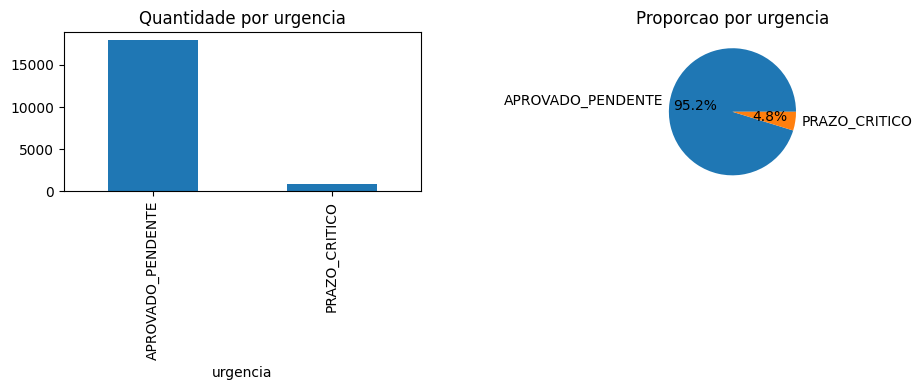

In [16]:
por_urgencia = df_parado["urgencia"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
por_urgencia.plot(kind="bar", ax=axes[0])
axes[0].set_title("Quantidade por urgencia")

por_urgencia.plot(kind="pie", ax=axes[1], autopct="%1.1f%%")
axes[1].set_title("Proporcao por urgencia")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [17]:
colunas = ["urgencia", "nome_beneficiario_plano_acao", "uf_beneficiario_plano_acao",
           "setor", "objeto_executor", "valor_total", "nome_parlamentar_emenda_plano_acao", "dias_para_prazo"]

df_leads = df_parado[colunas].dropna(subset=["dias_para_prazo"]).copy()
df_leads["dias_para_prazo"] = df_leads["dias_para_prazo"].astype(int)

print(f"Leads com prazo definido: {len(df_leads)}")
df_leads.head(20)

Leads com prazo definido: 13900


,urgencia,nome_beneficiario_plano_acao,uf_beneficiario_plano_acao,setor,objeto_executor,valor_total,nome_parlamentar_emenda_plano_acao,dias_para_prazo
1432,PRAZO_CRITICO,MUNICIPIO DE AREIA BRANCA,RN,Turismo,MARCHA PARA JESUS \n\nAs metas estão relaciona...,25022.0,General Girão,-685
2536,PRAZO_CRITICO,MUNICIPIO DE FELIPE GUERRA,RN,Turismo,Contratação da Atração Musical - Banda Calcinh...,374442.0,João Maia,-685
2795,PRAZO_CRITICO,MUNICIPIO DE ACARI,RN,Turismo,"EVENTO REALIZADO NO MUNICÍPIO DE ACARI/RN, NA ...",25022.0,General Girão,-685
2914,PRAZO_CRITICO,MUNICIPIO DE ACARI,RN,Turismo,1. APRESENTAÇÃO ARTÍSTICA (SHOW MUSICAL) DO CA...,260000.0,Styvenson Valentim,-685
3599,PRAZO_CRITICO,CARNAÚBA DOS DANTAS,RN,Turismo,"Termo de Convênio 005/2024 que entre si, celeb...",200000.0,Vicentinho,-685
9658,PRAZO_CRITICO,CAPOEIRAS,PE,Difusão Cultural | Turismo,CONTRATAÇÃO MEDIANTE INEXIGIBILIDADE PARA SHOW...,500000.0,Ossesio Silva,-685
2436,PRAZO_CRITICO,JUCATI,PE,Difusão Cultural | Educação Básica | Energia E...,CONTRATAÇÃO DE ATRAÇÕES ARTISTICAS;\nCONTRATAÇ...,700000.0,Luciano Bivar,-624
10070,PRAZO_CRITICO,MUNICIPIO DE PRACUUBA,AP,Educação Infantil | Infraestrutura Urbana | L...,Elaboração de Projetos; Aquisição de Merenda E...,2200000.0,Davi Alcolumbre,-593
1571,PRAZO_CRITICO,MUNICIPIO DE SANTA INES,BA,Infraestrutura Urbana,"EXECUÇÃO de 3.824,20M² DE PAVIMENTAÇÃO EM PARA...",400000.0,Jorge Solla,-563
2366,PRAZO_CRITICO,MUNICIPIO DE ILHA COMPRIDA,SP,Turismo,"Festa Maratayama Tradicional no município, a F...",200000.0,Marangoni,-563
